In [2]:
from rasterio.io import MemoryFile
import pandas as pd
import os
import matplotlib.pyplot as plt
import rasterio
import numpy as np

### 1. Datos de las boyas

In [16]:
path = "boyaUPCT"
filename = "locBoyasUPCT.csv"
loc_boyas = pd.read_csv(os.path.join(path, filename)).iloc[:,:3]
loc_boyas.head(3)

,CodPuntoControl,Latitud,Longitud
0,CTD-1,37.811800,-0.784483
1,CTD-2,37.760617,-0.807800
2,CTD-3,37.761783,-0.783550


In [10]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes_boyas = {}
# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    for archivo in archivos_csv:     
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        if nombre_variable in ["Clorofila"]:
            dataframes_boyas[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)
for key, df in dataframes_boyas.items():
    df['Date'] = pd.to_datetime(df['Date'])

### 2. Representación por profundidad y por boya

In [143]:
dataframes_boyas["CTD8_Clorofila"]["Date"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 373 entries, 0 to 372
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
373 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.0 KB


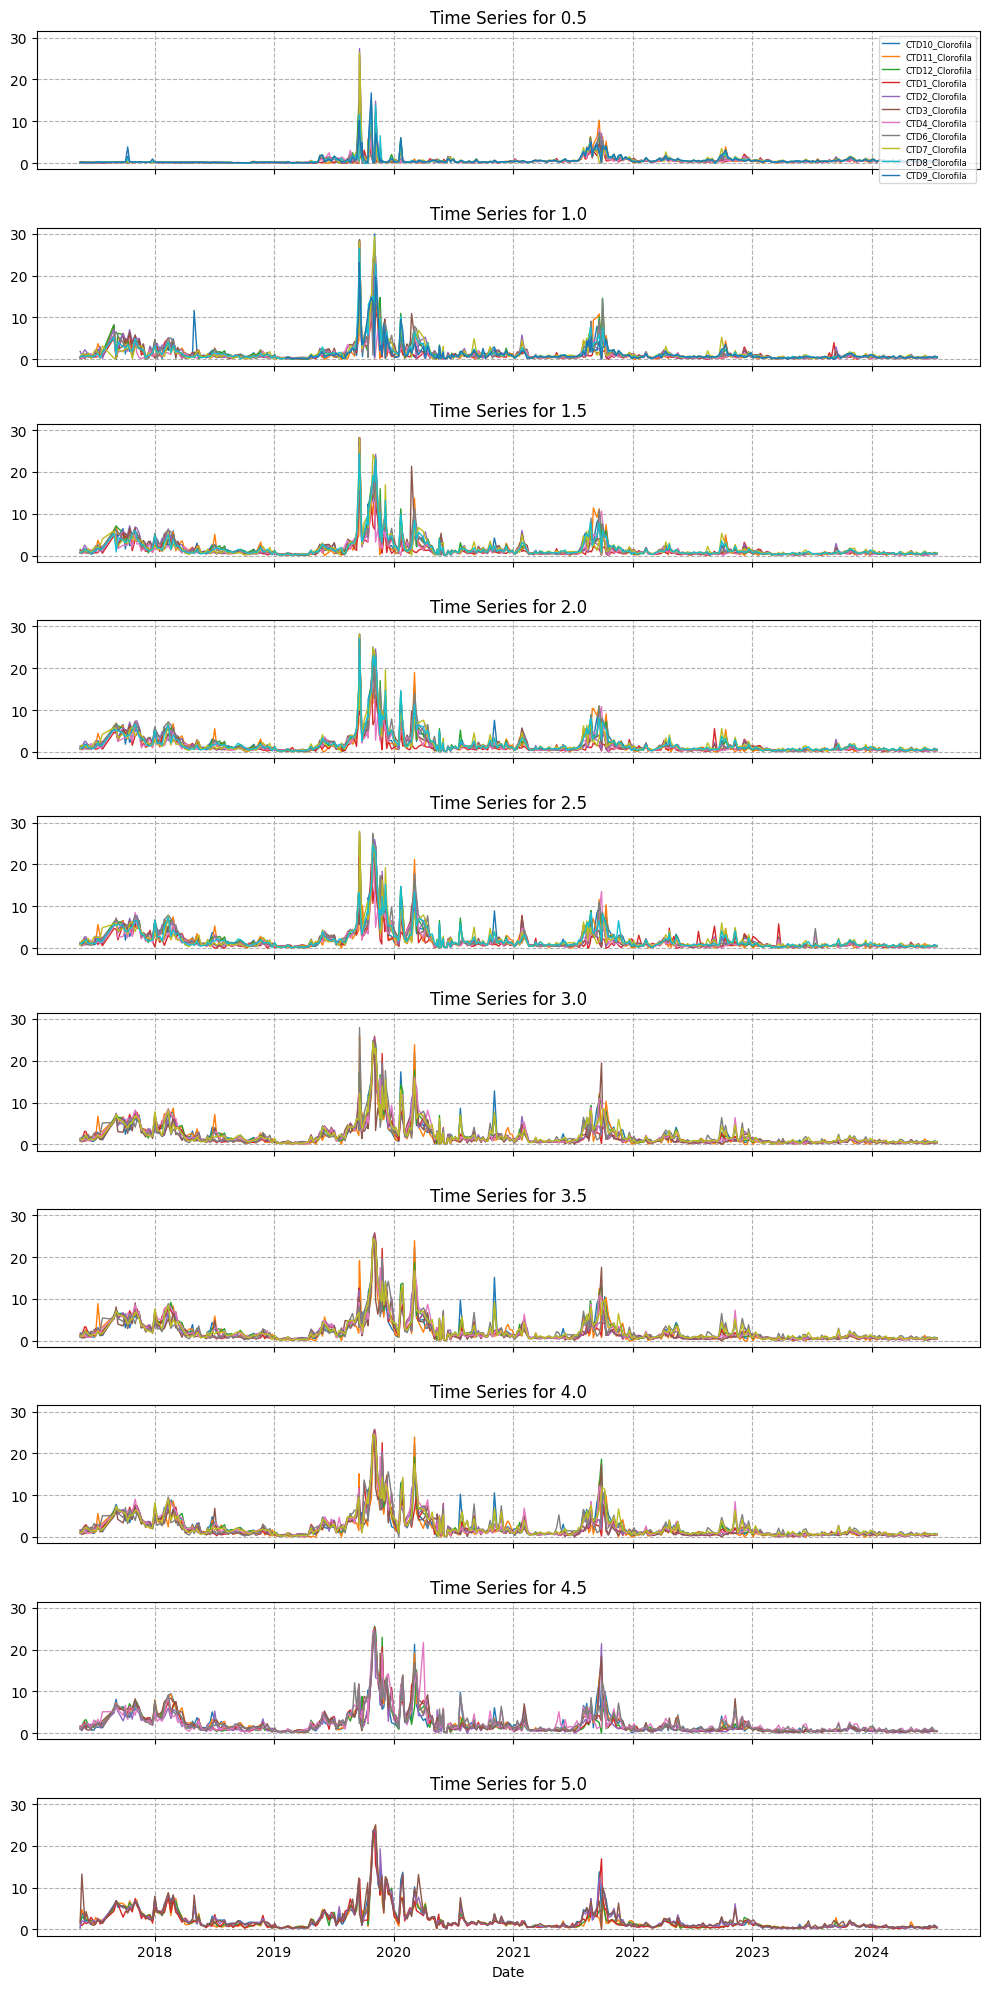

In [4]:
def plot_depths(df_dict):
    columns = ['0.5', '1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0'] #['0.5', '1.0', '1.5', '2.0', '2.5', '3.0', '3.5']
    num_plots = len(columns)
    
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 2 * num_plots), sharex=True, sharey=True)
    
    for i, col in enumerate(columns):
        for name in sorted(df_dict.keys()):
            df = df_dict[name]
            if col in df.columns:
                axes[i].plot(df['Date'], df[col], label=name, linewidth=1)
        
        axes[i].set_title(f'Time Series for {col}')
        axes[i].grid(linestyle='--')
        
        if i == 0:
            axes[i].legend(loc="upper right", fontsize = 6)
    
    plt.xlabel('Date')
    fig.tight_layout()
    plt.show()

plot_depths(dataframes_boyas)

In [11]:
dataframes_boyas["CTD5_Clorofila"]

,Date,0.0,-1.0,-2.0,-3.0,-4.0,-5.0,Unnamed: 7
0,2016-08-09,0.21,0.38,0.36,NaN,NaN,NaN,NaN
1,2016-08-25,0.44,0.17,0.60,NaN,NaN,NaN,NaN
2,2016-08-30,1.67,1.67,2.40,NaN,NaN,NaN,NaN
3,2016-09-06,NaN,0.85,1.52,NaN,NaN,NaN,NaN
4,2016-09-08,0.94,0.80,1.60,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
375,2024-02-20,0.18,0.20,0.21,0.22,0.26,0.29,NaN
376,2024-03-07,0.18,0.17,0.22,0.23,0.26,0.28,NaN
377,2024-03-13,0.27,0.28,0.28,0.24,0.24,0.25,NaN
378,2024-03-20,0.19,0.23,0.24,0.27,0.27,0.25,NaN


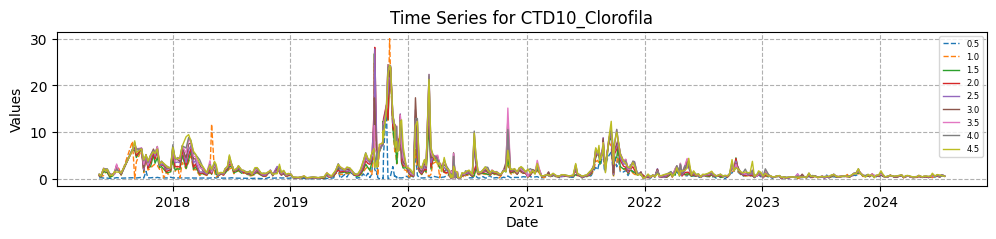

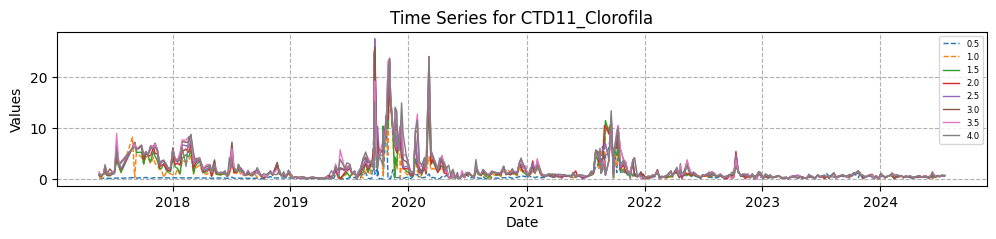

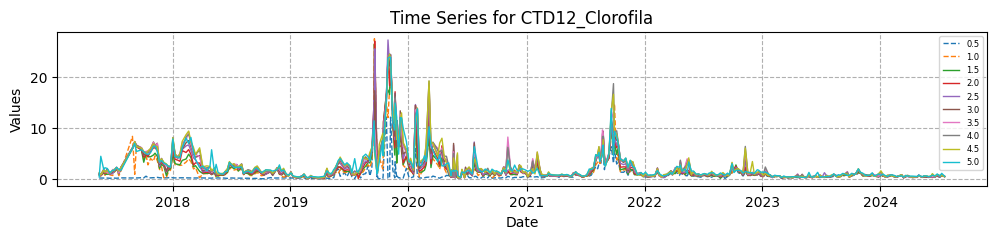

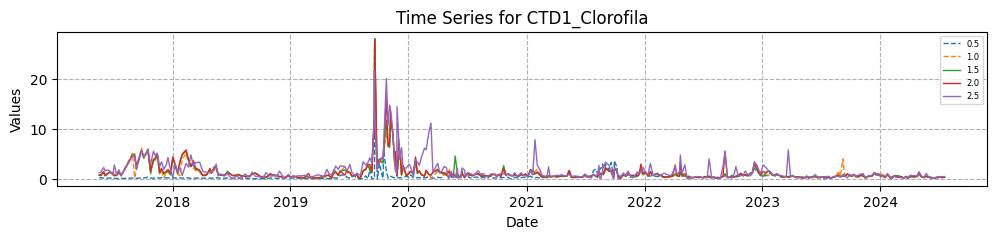

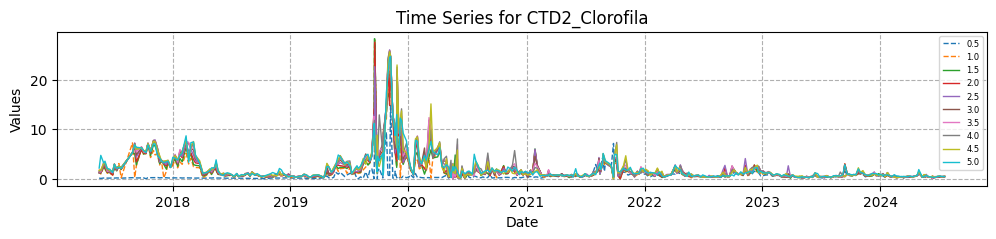

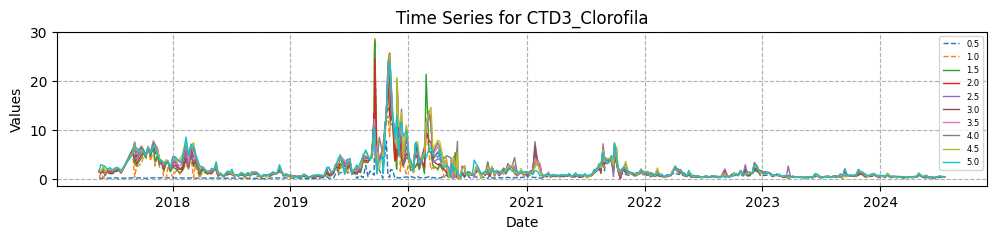

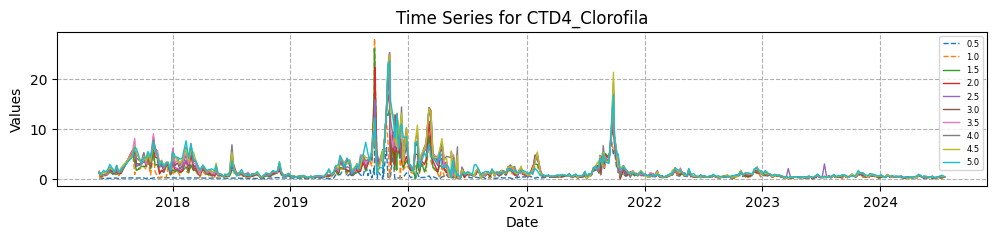

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


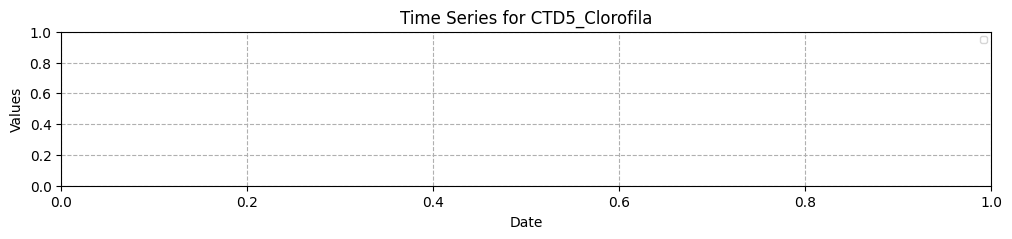

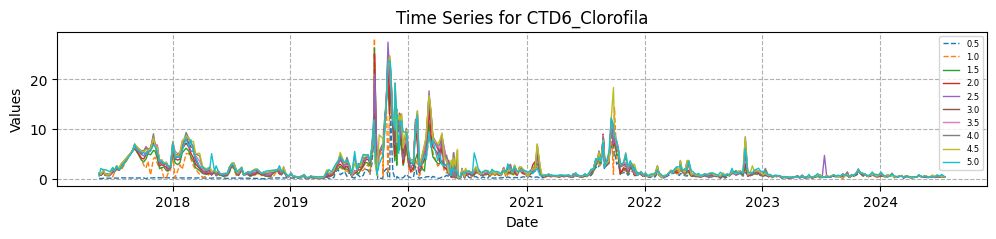

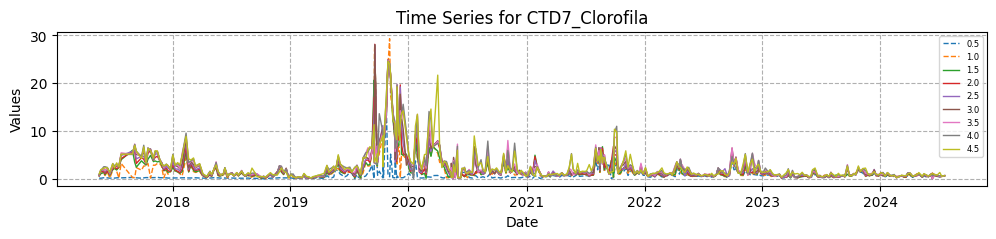

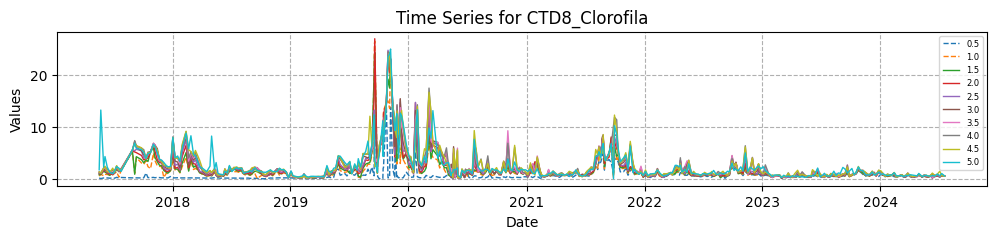

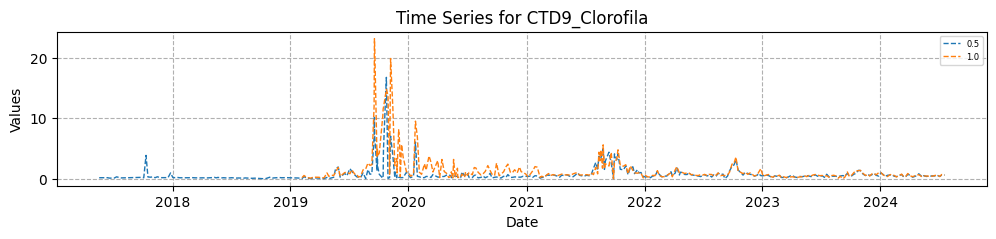

In [8]:
def plot_buoys(df_dict):
    for name in sorted(df_dict.keys()):
        df = df_dict[name]
        fig, ax = plt.subplots(figsize=(12, 2))
        columns = ['0.5','1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
        for col in columns:
            df = df_dict[name]
            if col in df.columns:
                if col != 'Date':
                    linestyle = '--' if col in ['0.5', '1.0'] else '-'
                    ax.plot(df['Date'], df[col], label=col, linewidth=1, linestyle = linestyle)
        
        ax.set_title(f'Time Series for {name}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Values')
        ax.legend(loc="upper right", fontsize = 6)
        ax.grid(linestyle='--')
        plt.show()

plot_buoys(dataframes_boyas)

In [127]:
dataframes_boyas["CTD8_Clorofila"]

,Date,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
0,2017-05-19,0.136957,0.517990,0.760704,0.966274,1.123300,1.307620,1.121814,1.019654,1.280418,1.720690
1,2017-05-24,0.029324,0.837571,0.796229,0.937800,1.102495,1.086841,1.036466,1.063770,1.108055,13.246256
2,2017-06-02,0.150199,0.588838,1.458824,1.519602,1.706818,1.677263,1.964820,2.129702,2.003898,2.248727
3,2017-06-06,0.133297,0.845602,1.279529,1.774988,2.079440,2.147534,2.129043,2.272362,2.413664,4.277684
4,2017-06-13,0.156576,0.820865,1.035338,1.015093,1.076005,1.085870,1.461331,1.901479,1.371172,2.240960
...,...,...,...,...,...,...,...,...,...,...,...
368,2024-06-18,0.412272,0.416279,0.443625,0.620974,0.516357,0.503450,0.551666,0.535557,0.560739,0.535561
369,2024-06-25,0.520893,0.582729,0.624059,0.497638,0.566231,0.613383,0.803834,0.813723,0.846333,0.906323
370,2024-07-03,0.346139,0.376814,0.380433,0.410119,0.409162,0.480780,0.476765,0.523853,1.445895,0.581046
371,2024-07-09,0.522134,0.538268,0.536604,0.629917,0.632249,0.667685,0.686452,0.720019,0.587295,1.007865


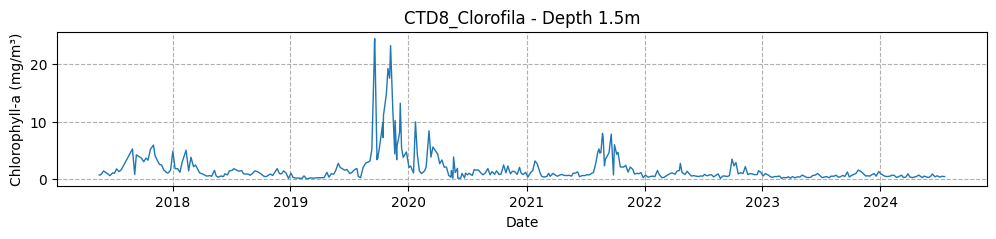

In [140]:
def plot_buoys(df_dict):
    for name in ["CTD8_Clorofila"]:
        depth = 1.5
        df = df_dict[name]
        fig, ax = plt.subplots(figsize=(12, 2))
        for col in [depth]:
            if col != 'Date':
                ax.plot(df['Date'], df[str(depth)], label=col, linewidth=1.0)
        
        ax.set_title(f'{name} - Depth 1.5m')
        ax.set_xlabel('Date')
        ax.set_ylabel('Chlorophyll-a (mg/m³)')
        #ax.legend(loc="upper right", fontsize = 6)
        ax.grid(linestyle='--')
        plt.savefig("saved_files/Clorofila_boya.pdf")
        plt.show()
        

plot_buoys(dataframes_boyas)


De aquí descartamos las boyas CTD5 y CTD9.

¿Qué profundidad usamos? Después de ver las gráficas quitando las líneas de 0.5 y 1.0 m, parece que el resto de profundidades se comportan de forma similar, así que hacemos la media de todas las profundidades a partir de 1.5m. 

### 3. Clorofila promediada para las profundidades >1m

In [12]:
# Añadimos una columna que es la media de todas las columnas excepto las de 0.5 y 1.0 m

def add_average_column(df_dict):
    for name, df in df_dict.items():
        df = df.copy()  # Ensure we don't modify the original data directly
        
        columns = ['0.5', '1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
        
        # Select columns to average (excluding '0.5' and '1.0')
        cols_to_avg = [col for col in columns if col in df.columns and col not in ['0.5', '1.0']]
        
        # Compute the mean and add a new column
        if cols_to_avg:
            df['Average'] = df[cols_to_avg].mean(axis=1)
        
        # Update the dictionary with the modified DataFrame
        dataframes_boyas[name] = df

add_average_column(dataframes_boyas)

In [13]:
def create_combined_dataframe(df_dict):
    data = []
    
    for name in sorted(df_dict.keys()):
        if name.startswith("CTD5") or name.startswith("CTD9"):
            continue  # Ignore CTD5 and CTD9
        
        buoy_name = name.split('_')[0]  # Extract buoy name (CTD1, CTD2, etc.)
        df = df_dict[name]
        
        if 'Average' in df.columns:
            for _, row in df.iterrows():
                data.append({'Date': row['Date'], 'Buoy': buoy_name, 'Chl': row['Average']})
    
    combined_df = pd.DataFrame(data).sort_values(by=["Date", "Buoy"])
    return combined_df

df_boyas = create_combined_dataframe(dataframes_boyas)

In [48]:
df_boyas.head(3)

,Date,Buoy,Chl
1119,2017-05-19,CTD1,0.883072
0,2017-05-19,CTD10,0.836520
373,2017-05-19,CTD11,0.899332


In [43]:
df_boyas["Date"].unique()

<DatetimeArray>
['2017-05-19 00:00:00', '2017-05-24 00:00:00', '2017-06-02 00:00:00',
 '2017-06-06 00:00:00', '2017-06-13 00:00:00', '2017-06-21 00:00:00',
 '2017-06-30 00:00:00', '2017-07-05 00:00:00', '2017-07-12 00:00:00',
 '2017-07-19 00:00:00',
 ...
 '2024-05-15 00:00:00', '2024-05-22 00:00:00', '2024-05-29 00:00:00',
 '2024-06-05 00:00:00', '2024-06-10 00:00:00', '2024-06-18 00:00:00',
 '2024-06-25 00:00:00', '2024-07-03 00:00:00', '2024-07-09 00:00:00',
 '2024-07-18 00:00:00']
Length: 373, dtype: datetime64[ns]

bands: ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12","SCL"]

In [24]:
def coordenadas_a_pixel(response, lat, lon, buoy):
    """
    Extract pixel value and coordinates from a TIFF response using latitude and longitude.
    """
    # Read the TIFF content from the response
    with MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            # Read the first band of the TIFF file
            index_array = src.read(1)  # Assuming single-band data
            
            # Get the pixel coordinates for the given latitude and longitude
            row, col = src.index(lon, lat)
            
            # Extract the value from the index array
            value = index_array[row, col]
            
            # Print for debugging
            print(f"Loc Buoy {buoy} - Pixel value: {value}, Latitude: {lat}, Longitude: {lon}")
            
            return row, col, value

In [25]:
def coordenadas_a_pixel_from_file(dataset, lat, lon, buoy):
    """
    Extract pixel values from all bands in a TIFF dataset using latitude and longitude.
    """
    # Get the pixel coordinates for the given latitude and longitude
    row, col = dataset.index(lon, lat)
    
    # Extract values from all bands
    values = [dataset.read(band)[row, col] for band in range(1, dataset.count + 1)]
    
    # Print for debugging
    print(f"Loc Buoy {buoy} - Pixel values: {values}, Latitude: {lat}, Longitude: {lon}")
    
    return row, col, values

In [ ]:

# Example of usage:
tiff_path = os.path.join("Copernicus/sentinelAntonioMI", "2021-07-24.tiff")
with rasterio.open(tiff_path) as dataset:
    print(dataset.index(lon, lat))
    print()
    row, col, values = coordenadas_a_pixel_from_file(dataset, lat=lat, lon=lon, buoy="CTD1")


### 4. Imágenes de satélite y datos de boya en la misma fecha en DataFrame

In [14]:
def get_matching_tiff_files(folder_path, dataframe):
    """
    Get a list of TIFF files in the folder that match the dates in the given dataframe.
    """
    # Extract unique dates from the dataframe and convert them to string format (assuming YYYY-MM-DD)
    available_dates = set(dataframe['Date'].astype(str))
    # List all TIFF files in the directory
    all_files = os.listdir(folder_path)
    # Filter files that match any of the available dates
    matching_files = [f for f in all_files if f.endswith('.tiff') and f.split('.tiff')[0] in available_dates]
    return matching_files

folder_path = "Copernicus/sentinelAntonioMI"
matching_tiff_files = get_matching_tiff_files(folder_path, dataframes_boyas["CTD10_Clorofila"])

print(sorted(matching_tiff_files))
print(len((matching_tiff_files)))

['2017-06-30.tiff', '2017-07-05.tiff', '2017-11-22.tiff', '2018-01-31.tiff', '2018-02-20.tiff', '2018-03-07.tiff', '2018-05-11.tiff', '2018-05-16.tiff', '2018-06-20.tiff', '2018-07-10.tiff', '2018-08-09.tiff', '2018-08-14.tiff', '2018-08-29.tiff', '2018-09-13.tiff', '2018-10-03.tiff', '2018-11-07.tiff', '2019-02-20.tiff', '2019-03-12.tiff', '2019-06-25.tiff', '2019-07-10.tiff', '2019-07-30.tiff', '2019-08-14.tiff', '2019-08-29.tiff', '2019-09-18.tiff', '2019-09-28.tiff', '2019-10-03.tiff', '2019-11-07.tiff', '2019-11-27.tiff', '2019-12-07.tiff', '2020-02-20.tiff', '2020-02-25.tiff', '2020-03-11.tiff', '2020-05-05.tiff', '2020-05-20.tiff', '2020-08-13.tiff', '2020-12-21.tiff', '2021-01-05.tiff', '2021-02-24.tiff', '2021-04-20.tiff', '2021-05-20.tiff', '2021-05-25.tiff', '2021-06-14.tiff', '2021-07-14.tiff', '2021-08-03.tiff', '2021-08-13.tiff', '2021-09-02.tiff', '2021-10-07.tiff', '2021-11-11.tiff', '2021-12-01.tiff', '2021-12-21.tiff', '2022-02-24.tiff', '2022-06-24.tiff', '2022-07-14

Lista de archivos que sirven, quitando las que mirando archivo a archivo hemos visto que tienen nubes:

2017-06-30, 2018-01-31, 2018-02-20, 2018-03-07, 2018-05-11, 2018-05-16, 2018-06-20, 2018-07-10, 2018-08-09, 2018-08-14, 2018-08-29, 2018-10-03, 2018-11-07, 2019-02-20, 2019-03-12, 2019-06-25, 2019-07-10, 2019-08-14, 2019-09-18, 2019-10-03, 2019-11-27, 2020-02-20, 2020-02-25, 2020-03-11, 2020-05-05, 2020-05-20, 2020-08-13, 2020-12-21

2021-01-05, 2021-04-20, 2021-06-14, 2021-07-14, 2021-08-03, 2021-08-13, 2021-11-11, 2021-12-01, 2022-02-24, 2022-06-24, 2022-07-14, 2022-08-03, 2022-09-07, 2023-01-10, 2023-01-20?, 2023-03-01, 2023-03-16, 2023-04-20, 2023-05-25, 2023-07-19, 2023-09-07, 2023-09-27, 2023-11-16, 2024-04-24, 2024-05-29, 2024-06-18, 2024-07-03, 2024-07-18

Las descartadas por nubes son:
2017-07-05, 2017-11-22, 2018-09-13, 2019-07-30, 2019-08-29, 2019-09-28, 2019-11-07, 2019-12-07, 2021-02-24, 2021-05-20, 2021-05-25, 2021-09-02, 2021-10-07, 2021-12-21.

Hacemos una función que itere primero sobre las imágenes (tiff), y para cada una sobre las ubicaciones de las boyas, y de ahí saque el valor de todas las bandas

In [17]:
def extract_values_for_buoys(folder_path, loc_boyas, target_dates):
    """
    Extract pixel values from TIFF files for each buoy in loc_boyas and for each specified date.
    """
    results = []
    # Convert target dates to a set of string format
    target_dates = set(target_dates)
    # Iterate over target dates 
    for date in target_dates:
        tiff_file = os.path.join(folder_path, f"{date}.tiff")
        if os.path.exists(tiff_file):
            with rasterio.open(tiff_file) as dataset:
                print(f"Processing {tiff_file}")
                # Iterate over each buoy
                for _, row in loc_boyas.iterrows():
                    buoy_id = row["CodPuntoControl"].replace('-', '')
                    lat = row["Latitud"]
                    lon = row["Longitud"]
                    try:
                        row_idx, col_idx = dataset.index(lon, lat)
                        values = [dataset.read(band)[row_idx, col_idx] for band in range(1, dataset.count + 1)]
                        results.append({
                            "Date": date,
                            "Buoy": buoy_id,
                            "Latitude": lat,
                            "Longitude": lon,
                            **{f"Band_{i+1}": val for i, val in enumerate(values)}
                        })
                    except IndexError:
                        print(f"Skipping {buoy_id} on {date}: Coordinates out of raster bounds")

    # Convert results to a DataFrame
    return pd.DataFrame(results)


folder_path = "Copernicus/sentinelAntonioMI"
target_dates = [
    "2017-06-30", "2018-01-31", "2018-02-20", "2018-03-07", "2018-05-11", "2018-05-16",
    "2018-06-20", "2018-07-10", "2018-08-09", "2018-08-14", "2018-08-29", "2018-10-03",
    "2018-11-07", "2019-02-20", "2019-03-12", "2019-06-25", "2019-07-10", "2019-08-14",
    "2019-09-18", "2019-10-03", "2019-11-27", "2020-02-20", "2020-02-25", "2020-03-11",
    "2020-05-05", "2020-05-20", "2020-08-13", "2020-12-21", "2021-01-05", "2021-04-20", 
    "2021-06-14", "2021-07-14", "2021-08-03", "2021-08-13", "2021-11-11", "2021-12-01",
    "2022-02-24", "2022-06-24", "2022-07-14", "2022-08-03", "2022-09-07", "2023-01-10", 
    "2023-01-20", "2023-03-01", "2023-03-16", "2023-04-20", "2023-05-25", "2023-07-19", 
    "2023-09-07", "2023-09-27", "2023-11-16", "2024-04-24", "2024-05-29", "2024-06-18", 
    "2024-07-03", "2024-07-18"
]

df_tiffs = extract_values_for_buoys(folder_path, loc_boyas, target_dates)
df_tiffs["Date"] = pd.to_datetime(df_tiffs["Date"])


Processing Copernicus/sentinelAntonioMI/2021-08-13.tiff
Processing Copernicus/sentinelAntonioMI/2018-11-07.tiff
Processing Copernicus/sentinelAntonioMI/2018-08-09.tiff
Processing Copernicus/sentinelAntonioMI/2023-07-19.tiff
Processing Copernicus/sentinelAntonioMI/2018-08-29.tiff
Processing Copernicus/sentinelAntonioMI/2023-05-25.tiff
Processing Copernicus/sentinelAntonioMI/2019-09-18.tiff
Processing Copernicus/sentinelAntonioMI/2024-07-03.tiff
Processing Copernicus/sentinelAntonioMI/2020-12-21.tiff
Processing Copernicus/sentinelAntonioMI/2021-01-05.tiff
Processing Copernicus/sentinelAntonioMI/2024-05-29.tiff
Processing Copernicus/sentinelAntonioMI/2021-04-20.tiff
Processing Copernicus/sentinelAntonioMI/2017-06-30.tiff
Processing Copernicus/sentinelAntonioMI/2018-01-31.tiff
Processing Copernicus/sentinelAntonioMI/2019-11-27.tiff
Processing Copernicus/sentinelAntonioMI/2021-12-01.tiff
Processing Copernicus/sentinelAntonioMI/2018-05-11.tiff
Processing Copernicus/sentinelAntonioMI/2024-04-

In [18]:
df_tiffs

,Date,Buoy,Latitude,Longitude,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13
0,2021-08-13,CTD1,37.811800,-0.784483,3,7,12,9,9,8,8,9,9,8,11,9,255
1,2021-08-13,CTD2,37.760617,-0.807800,6,9,12,12,11,10,11,11,10,9,11,8,255
2,2021-08-13,CTD3,37.761783,-0.783550,5,7,12,11,10,9,10,9,9,8,9,7,255
3,2021-08-13,CTD4,37.748233,-0.749617,1,7,9,7,6,6,6,8,6,6,8,7,255
4,2021-08-13,CTD5,37.740450,-0.727117,6,10,13,10,10,10,10,11,10,10,10,8,255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,2020-03-11,CTD8,37.694517,-0.810400,1,2,6,2,2,0,0,0,0,0,0,0,255
668,2020-03-11,CTD9,37.666817,-0.809683,2,6,11,5,2,0,0,0,0,0,0,0,255
669,2020-03-11,CTD10,37.659833,-0.781967,1,2,6,1,1,0,0,0,0,0,0,0,255
670,2020-03-11,CTD11,37.651800,-0.728883,0,1,6,1,0,0,0,0,0,0,0,0,255


#### 4.1 Fechas con datos de boyas pero no de satélite

In [51]:
bouy_dates = set(df_boyas["Date"].dt.strftime("%Y-%m-%d").tolist())
cloud_dates = ["2017-07-05", "2017-11-22", "2018-09-13", "2019-07-30", "2019-08-29", "2019-09-28", "2019-11-07", "2019-12-07", "2021-02-24", "2021-05-20", "2021-05-25", "2021-09-02", "2021-10-07", "2021-12-21"]
sync_dates = set(["2017-06-30", "2018-01-31", "2018-02-20", "2018-03-07", "2018-05-11", "2018-05-16", "2018-06-20", "2018-07-10", "2018-08-09", "2018-08-14", "2018-08-29", "2018-10-03", "2018-11-07", "2019-02-20", "2019-03-12", "2019-06-25", "2019-07-10", "2019-08-14", "2019-09-18", "2019-10-03", "2019-11-27", "2020-02-20", "2020-02-25", "2020-03-11", "2020-05-05", "2020-05-20", "2020-08-13", "2020-12-21", "2021-01-05", "2021-04-20", "2021-06-14", "2021-07-14", "2021-08-03", "2021-08-13", "2021-11-11", "2021-12-01", "2022-02-24", "2022-06-24", "2022-07-14", "2022-08-03", "2022-09-07", "2023-01-10", "2023-01-20", "2023-03-01", "2023-03-16", "2023-04-20", "2023-05-25", "2023-07-19", "2023-09-07", "2023-09-27", "2023-11-16", "2024-04-24", "2024-05-29", "2024-06-18", "2024-07-03", "2024-07-18"])

In [54]:
missing_dates = list(bouy_dates - sync_dates)

### 5. Merge para DataFrame final

In [19]:
df_boyas_tiffs = df_tiffs.merge(df_boyas, how="inner", on=["Date", "Buoy"])

In [20]:
df_boyas_tiffs.head(3)

,Date,Buoy,Latitude,Longitude,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Chl
0,2021-08-13,CTD1,37.811800,-0.784483,3,7,12,9,9,8,8,9,9,8,11,9,255,1.976337
1,2021-08-13,CTD2,37.760617,-0.807800,6,9,12,12,11,10,11,11,10,9,11,8,255,3.440385
2,2021-08-13,CTD3,37.761783,-0.783550,5,7,12,11,10,9,10,9,9,8,9,7,255,2.922179


In [52]:
df_boyas_tiffs.shape

(560, 18)

In [53]:
df_boyas_tiffs.to_csv("saved_files/df_boyas_tiffs.csv", index=False)

In [25]:
df = pd.read_csv("saved_files/df_boyas_tiffs.csv")
df['Date'] = pd.to_datetime(df['Date'])

In [26]:
df = df.drop(columns=["Latitude", "Longitude", "Band_8", "Band_9", "Band_10", "Band_11", "Band_12", "Band_13"])

In [27]:
df.head(3)

,Date,Buoy,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Chl
0,2024-04-24,CTD1,9,10,10,7,7,7,7,0.563823
1,2024-04-24,CTD2,10,11,11,7,7,6,7,0.676964
2,2024-04-24,CTD3,10,10,10,6,6,5,6,0.432991


### 6. Distribución de los datos (en valor y en el tiempo)

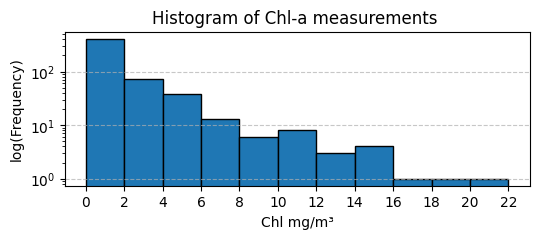

In [6]:
def plot_chl_histogram(df):
    if "Chl" in df.columns:
        plt.figure(figsize=(6, 2))
        log_scale = True
        plt.hist(df["Chl"], bins=range(0, int(df["Chl"].max()) + 2, 2), edgecolor="black", cumulative=False, log=log_scale)
        plt.title("Histogram of Chl-a measurements ")
        if log_scale==True:
            plt.ylabel("log(Frequency)")
        else:
            plt.ylabel("Frequency")
        plt.xlabel("Chl mg/m³")
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.xticks(range(0, int(df["Chl"].max()) + 2, 2))
        plt.show()
    else:
        print("Column 'Chl' not found in the dataframe.")

plot_chl_histogram(df)

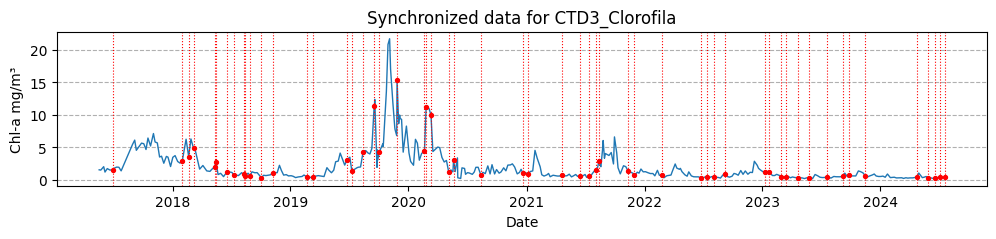

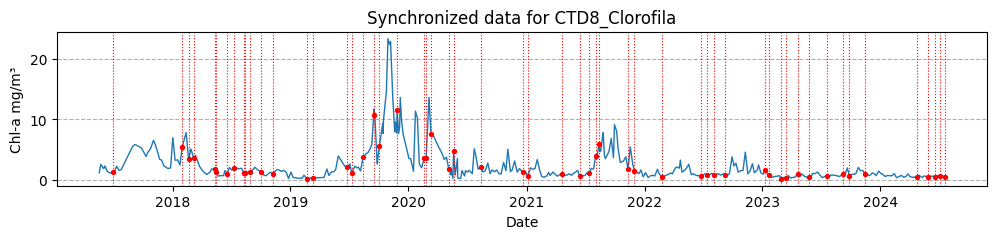

In [39]:
def plot_buoys(df_dict, dates):
    for name in sorted(['CTD3_Clorofila', 'CTD8_Clorofila']):
        df = df_dict[name]
        fig, ax = plt.subplots(figsize=(12, 2))
        columns = ['Average']
        for col in columns:
            df = df_dict[name]
            if col in df.columns:
                if col != 'Date':
                    ax.plot(df['Date'], df[col], label=col, linewidth=1)
        
        for date in dates:
            ax.axvline(x=date, color='red', linestyle=':', linewidth=0.8)  # Adjust color and style if needed

            for col in columns:
                if col in df.columns:
                    value = df.loc[df["Date"] == date, col].values  # Get corresponding value
                    if len(value) > 0:  # Ensure value exists
                        ax.scatter(date, value[0], color='red', s=8, zorder=3)  # Red dots


        ax.set_title(f'Synchronized data for {name}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Chl-a mg/m³')
        #ax.legend(loc="upper right", fontsize = 6)
        ax.grid(axis="y" ,linestyle='--')
        plt.show()

dates = df["Date"].unique()
plot_buoys(dataframes_boyas, dates)

In [85]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

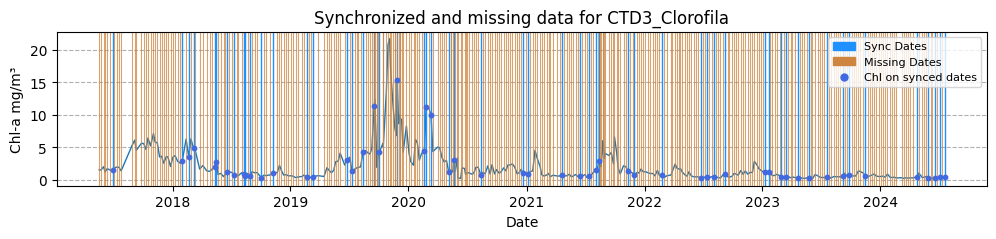

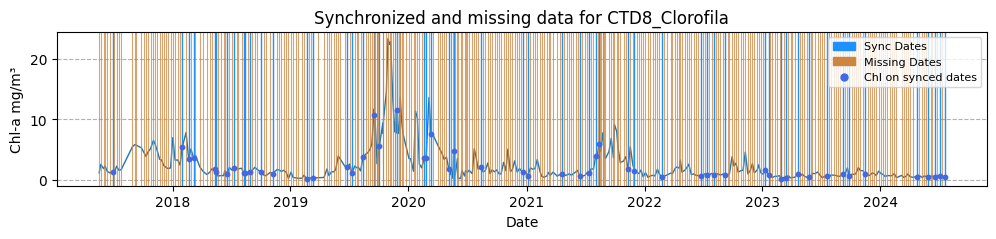

In [91]:
def plot_buoys(df_dict, dates, missing_dates):
    missing_dates = pd.to_datetime(missing_dates)
    for name in sorted(['CTD3_Clorofila', 'CTD8_Clorofila']):
        df = df_dict[name]
        fig, ax = plt.subplots(figsize=(12, 2))
        columns = ['Average']
        for col in columns:
            df = df_dict[name]
            if col in df.columns:
                if col != 'Date':
                    ax.plot(df['Date'], df[col], label=col, linewidth=1)
        
        for date in dates:
            ax.axvline(x=date, color='dodgerblue', linestyle='-', linewidth=1)  # Adjust color and style if needed
            for col in columns:
                if col in df.columns:
                    value = df.loc[df["Date"] == date, col].values  # Get corresponding value
                    if len(value) > 0:  # Ensure value exists
                        ax.scatter(date, value[0], color='royalblue', s=10, zorder=3)  # Red dots

        # Add blue vertical lines for missing_dates
        for date in missing_dates:
            ax.axvline(x=date, color='peru', linestyle='-', linewidth=0.8, alpha=0.75)

        sync_patch = mpatches.Patch(color='dodgerblue', label='Sync Dates')
        missing_patch = mpatches.Patch(color='peru', label='Missing Dates')
        sync_dot = mlines.Line2D([], [], color='royalblue', marker='o', linestyle='None', markersize=5, label='Chl on synced dates')
        ax.legend(handles=[sync_patch, missing_patch, sync_dot], loc="upper right", fontsize=8)

        ax.set_title(f'Synchronized and missing data for {name}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Chl-a mg/m³')
        ax.grid(axis="y" ,linestyle='--')
        plt.savefig("saved_files/missing_dates.pdf")
        plt.show()

dates = df["Date"].unique()
plot_buoys(dataframes_boyas, dates, missing_dates)

In [80]:
missing_dates

['2023-09-13',
 '2021-03-10',
 '2022-09-21',
 '2023-03-22',
 '2024-04-29',
 '2023-12-07',
 '2021-02-12',
 '2019-01-09',
 '2021-02-24',
 '2023-09-21',
 '2023-08-01',
 '2018-07-04',
 '2021-04-27',
 '2023-04-27',
 '2020-06-01',
 '2018-02-12',
 '2023-05-18',
 '2020-10-22',
 '2019-01-25',
 '2023-08-24',
 '2024-03-13',
 '2020-11-18',
 '2022-11-17',
 '2022-01-04',
 '2023-06-28',
 '2021-12-28',
 '2019-12-11',
 '2022-12-01',
 '2020-09-10',
 '2024-01-23',
 '2021-06-22',
 '2021-08-26',
 '2017-12-18',
 '2019-10-15',
 '2022-07-06',
 '2022-06-10',
 '2019-07-04',
 '2021-09-02',
 '2020-01-17',
 '2022-02-02',
 '2020-09-24',
 '2018-10-31',
 '2024-01-16',
 '2023-10-17',
 '2020-06-15',
 '2021-10-11',
 '2020-06-02',
 '2020-06-11',
 '2019-01-17',
 '2019-09-27',
 '2017-07-19',
 '2020-01-08',
 '2020-04-01',
 '2024-06-25',
 '2020-07-28',
 '2024-04-02',
 '2020-12-15',
 '2018-07-24',
 '2017-08-30',
 '2017-07-12',
 '2020-04-14',
 '2024-06-05',
 '2021-08-16',
 '2018-06-08',
 '2023-11-24',
 '2020-05-25',
 '2021-08-

### 6. Random Forest

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

In [44]:
X = df.loc[:, df.columns != "Value"]
y = df.loc[:, "Value"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=123)
model = RandomForestRegressor().fit(X_train, y_train)

prediction = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test,prediction))
cvrmse = rmse/np.mean(y_test)*100
r2 = r2_score(y_test, prediction)
print('Test RMSE: %.3f' % rmse)
print('Test CVRMSE: %.3f' % cvrmse)
print('Test R squared: %.3f' % r2)
print()
# Assuming your features are stored in a DataFrame called X_train
feature_importances = model.feature_importances_
# Create a DataFrame for better visualization
importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)
print(importances_df)

Test RMSE: 1.973
Test CVRMSE: 116.351
Test R squared: 0.436

  Feature  Importance
0  Band_1    0.212046
4  Band_5    0.173561
3  Band_4    0.150949
2  Band_3    0.144215
6  Band_7    0.120774
1  Band_2    0.120486
5  Band_6    0.077970


### 7. MLP

In [107]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras_tuner import BayesianOptimization
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

In [108]:
X = df.loc[:, df.columns != "Value"]
y = df.loc[:, "Value"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=123)
X_test, X_val, y_test, y_val = train_test_split( X_test, y_test, test_size=0.5, random_state=123)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)


In [111]:
n_features = X_train.shape[1]
n_timesteps = 1

def build_model(hp):
    model = Sequential()
    # Explicit input layer for MLP with flattened shape
    model.add(Input(shape=(n_features,)))  # Corrected input shape
    # Hidden layers with hyperparameter tuning
    hp_units1 = hp.Choice('input_unit1',[25,50,100])
    model.add(Dense(units=hp_units1, activation='relu'))
    
    hp_units2 = hp.Choice('input_unit2',[25,50,100])
    model.add(Dense(units=hp_units2, activation='relu'))
    
    # Dropout layer with hyperparameter tuning
    hp_dropout = hp.Float('Dropout_rate',min_value=0,max_value=0.4,step=0.1)
    model.add(Dropout(hp_dropout))
    
    # Output layer
    model.add(Dense(1))
    
    # Learning rate tuning
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        loss='mae',
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate)
    )
    return model

tuner= BayesianOptimization(build_model,
                                objective='val_loss', max_trials=30, num_initial_points=2, seed = 123, overwrite=True)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=10)
tuner.search(x=X_train, y=y_train, epochs=200, batch_size=128, validation_data=(X_val,y_val), verbose=2,
        shuffle=True, callbacks=[stop_early])
model = tuner.get_best_models(num_models=1)[0]

Trial 30 Complete [00h 00m 02s]
val_loss: 0.2965603470802307

Best val_loss So Far: 0.28125929832458496
Total elapsed time: 00h 01m 29s


In [115]:
y_pred = model.predict(X_test)
def metrics(test_y, prediction):
    rmse = np.sqrt(mean_squared_error(test_y,prediction))
    cvrmse = rmse/np.mean(test_y)*100
    r2 = r2_score(test_y, prediction)
    mape = mean_absolute_percentage_error(y_test, prediction)
    print('Test RMSE: %.2f' % rmse)
    print('Test CVRMSE: %.2f' % cvrmse)
    print('Test R squared: %.2f' % r2)
    print('Test MAPE: %.2f' % mape)
    return
#model.save('model_cons_lstm_' + i + '_0'+ str(l) + '_pred' + j + '_prev' + str(k) + '.h5')
metrics(y_test, y_pred)

2/2 [==============================] - 0s 2ms/step


Test RMSE: 0.37
Test CVRMSE: 65.52
Test R squared: 0.24
Test MAPE: 0.50
